# Comparacion DF vs Shooting + Sturm sequence (Litio)

Este notebook compara los estados $2s, 3s, 4s, 2p, 3p, 3d$ en energias usando:
- Diferencias Finitas (DF) desde `finite-diferences/energias_litio_leonardo.dat`
- Shooting method desde `shooting-method/energias_shooting_fortran.dat`

Tambien compara funciones radiales con una tercera fuente:
- Sturm sequence desde `sturmSequence/LITIO_STURM0.DAT` (canal s) y `sturmSequence/LITIO_STURM1.DAT` (canal p)

La tabla energetica incluye paper, DF y shooting; Sturm se agrega en la comparacion radial.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import time
from IPython.display import Markdown, display

In [10]:
base = Path('.')
df_dir = base / 'finite-diferences'
shoot_dir = base / 'shooting-method'
sturm_dir = base / 'sturmSequence'

f_df_e = df_dir / 'energias_litio_leonardo.dat'
f_shoot_e = shoot_dir / 'energias_shooting_fortran.dat'
f_df_w = df_dir / 'funciones_radiales_litio_fortran_leonardo.DAT'
f_shoot_w = shoot_dir / 'funciones_shooting_fortran.dat'
f_sturm_s = sturm_dir / 'LITIO_STURM0.DAT'
f_sturm_p = sturm_dir / 'LITIO_STURM1.DAT'

for fp in [f_df_e, f_shoot_e, f_df_w, f_shoot_w, f_sturm_s, f_sturm_p]:
    if not fp.exists():
        raise FileNotFoundError(f'No existe: {fp}')

print('OK archivos encontrados para DF (Leonardo), shooting y Sturm sequence.')

OK archivos encontrados para DF (Leonardo), shooting y Sturm sequence.


In [11]:
states = ['2s', '3s', '4s', '2p', '3p', '3d']

paper = pd.DataFrame({
    'Estado': ['2s', '3s', '4s', '2p', '3p', '3d'],
    'E_calc_paper_eV': [-4.6994, -1.8527, -0.7201, -3.4306, -1.5050, -1.5048],
    'E_exp_eV': [-5.39, -2.02, -1.05, -3.54, -1.56, -1.51],
    'At_Hidrogeno_eV': [-3.401, -1.512, -0.850, -3.401, -1.512, -1.512],
})

def load_energy_table(path):
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[0]
            try:
                out[label] = float(parts[-1])
            except ValueError:
                continue
    return out

df_e = load_energy_table(f_df_e)
shoot_e = load_energy_table(f_shoot_e)

print('Energias DF (Leonardo):', df_e)
print('Energias shooting:', shoot_e)

Energias DF (Leonardo): {'2s': -4.7013101152239605, '3s': -1.8534940084799238, '4s': -0.7204496090941008, '2p': -3.4320664686596998, '3p': -1.5056224910004408, '4p': -0.4627173990839746, '3d': -1.5054203873022018}
Energias shooting: {'2s': -4.844254977052, '3s': -1.889620370906, '4s': -0.749455814063, '2p': -3.432395973171, '3p': -1.505711696681, '3d': -1.505711696681}


In [12]:
sturm_e = {
    '2s': -4.843899925619266,
    '3s': -1.8892850761704838,
    '4s': -0.7494196762770297,
    '2p': -3.4320668372815932,
    '3p': -1.5056226314273760,
    '3d': -1.5054203872518701,
}

table = paper.copy()
table['E_DF_eV'] = table['Estado'].map(df_e)
table['E_shooting_eV'] = table['Estado'].map(shoot_e)
table['E_sturm_eV'] = table['Estado'].map(sturm_e)

# DF se toma como referencia
table['Delta_shoot_vs_DF'] = table['E_shooting_eV'] - table['E_DF_eV']
table['Delta_sturm_vs_DF'] = table['E_sturm_eV'] - table['E_DF_eV']

pretty = table[['Estado', 'E_DF_eV', 'E_shooting_eV', 'E_sturm_eV', 'Delta_shoot_vs_DF', 'Delta_sturm_vs_DF']].copy()
pretty = pretty.round(6)

lines = []
lines.append('## Tabla bonita: Shooting y Sturm vs DF (referencia)')
lines.append('')
lines.append('$$\\Delta E = E_{\\mathrm{metodo}} - E_{\\mathrm{DF}}$$')
lines.append('')
lines.append('| Estado | E_DF (eV) | E_shooting (eV) | E_sturm (eV) | Delta Shooting-DF (eV) | Delta Sturm-DF (eV) |')
lines.append('|---|---:|---:|---:|---:|---:|')
for _, row in pretty.iterrows():
    lines.append(f"| {row['Estado']} | {row['E_DF_eV']:.6f} | {row['E_shooting_eV']:.6f} | {row['E_sturm_eV']:.6f} | {row['Delta_shoot_vs_DF']:.6f} | {row['Delta_sturm_vs_DF']:.6f} |")

display(Markdown('\n'.join(lines)))
table

## Tabla bonita: Shooting y Sturm vs DF (referencia)

$$\Delta E = E_{\mathrm{metodo}} - E_{\mathrm{DF}}$$

| Estado | E_DF (eV) | E_shooting (eV) | E_sturm (eV) | Delta Shooting-DF (eV) | Delta Sturm-DF (eV) |
|---|---:|---:|---:|---:|---:|
| 2s | -4.701310 | -4.844255 | -4.843900 | -0.142945 | -0.142590 |
| 3s | -1.853494 | -1.889620 | -1.889285 | -0.036126 | -0.035791 |
| 4s | -0.720450 | -0.749456 | -0.749420 | -0.029006 | -0.028970 |
| 2p | -3.432066 | -3.432396 | -3.432067 | -0.000330 | -0.000000 |
| 3p | -1.505622 | -1.505712 | -1.505623 | -0.000089 | -0.000000 |
| 3d | -1.505420 | -1.505712 | -1.505420 | -0.000291 | 0.000000 |

,Estado,E_calc_paper_eV,E_exp_eV,At_Hidrogeno_eV,E_DF_eV,E_shooting_eV,E_sturm_eV,Delta_shoot_vs_DF,Delta_sturm_vs_DF
0,2s,-4.6994,-5.39,-3.401,-4.701310,-4.844255,-4.843900,-0.142945,-1.425898e-01
1,3s,-1.8527,-2.02,-1.512,-1.853494,-1.889620,-1.889285,-0.036126,-3.579107e-02
2,4s,-0.7201,-1.05,-0.850,-0.720450,-0.749456,-0.749420,-0.029006,-2.897007e-02
3,2p,-3.4306,-3.54,-3.401,-3.432066,-3.432396,-3.432067,-0.000330,-3.686219e-07
4,3p,-1.5050,-1.56,-1.512,-1.505622,-1.505712,-1.505623,-0.000089,-1.404269e-07
5,3d,-1.5048,-1.51,-1.512,-1.505420,-1.505712,-1.505420,-0.000291,5.033174e-11


In [13]:
# Error relativo de cada metodo respecto a DF (referencia)
eps = 1e-14
err_sh = np.abs(table['E_shooting_eV'] - table['E_DF_eV']) / (np.abs(table['E_DF_eV']) + eps)
err_st = np.abs(table['E_sturm_eV'] - table['E_DF_eV']) / (np.abs(table['E_DF_eV']) + eps)

err_sh = err_sh.to_numpy(dtype=float)
err_st = err_st.to_numpy(dtype=float)

print('Estado | err_rel(shooting vs DF) | err_rel(sturm vs DF)')
for st, e1, e2 in zip(table['Estado'], err_sh, err_st):
    print(f"{st:>3} | {e1:>22.4e} | {e2:>18.4e}")

Estado | err_rel(shooting vs DF) | err_rel(sturm vs DF)
 2s |             3.0405e-02 |         3.0330e-02
 3s |             1.9491e-02 |         1.9310e-02
 4s |             4.0261e-02 |         4.0211e-02
 2p |             9.6008e-05 |         1.0741e-07
 3p |             5.9248e-05 |         9.3268e-08
 3d |             1.9351e-04 |         3.3434e-11


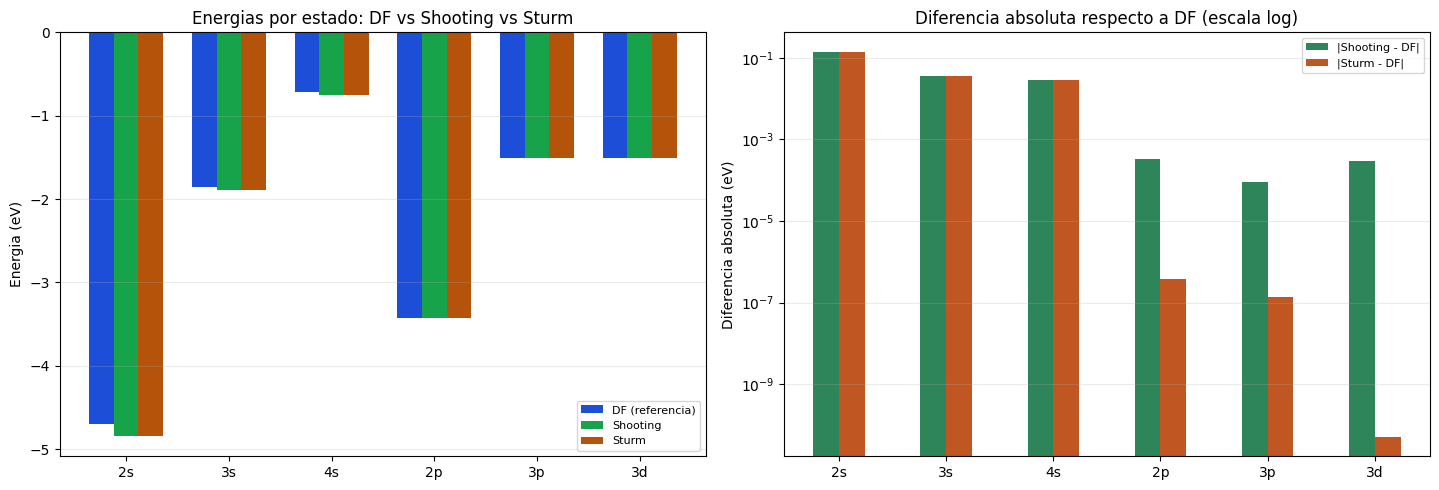

In [14]:
x = np.arange(len(states))
w = 0.24

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.0))

# Panel 1: comparacion energetica entre metodos numericos
ax[0].bar(x - w, table['E_DF_eV'], width=w, label='DF (referencia)', color='#1d4ed8')
ax[0].bar(x, table['E_shooting_eV'], width=w, label='Shooting', color='#16a34a')
ax[0].bar(x + w, table['E_sturm_eV'], width=w, label='Sturm', color='#b45309')
ax[0].set_xticks(x)
ax[0].set_xticklabels(states)
ax[0].set_ylabel('Energia (eV)')
ax[0].set_title('Energias por estado: DF vs Shooting vs Sturm')
ax[0].grid(True, axis='y', alpha=0.25)
ax[0].legend(fontsize=8)

# Panel 2: diferencias absolutas respecto a DF
ax[1].bar(x - 0.5*w, np.abs(table['Delta_shoot_vs_DF']), width=w, label='|Shooting - DF|', color='#2f855a')
ax[1].bar(x + 0.5*w, np.abs(table['Delta_sturm_vs_DF']), width=w, label='|Sturm - DF|', color='#c05621')
ax[1].set_xticks(x)
ax[1].set_xticklabels(states)
ax[1].set_yscale('log')
ax[1].set_ylabel('Diferencia absoluta (eV)')
ax[1].set_title('Diferencia absoluta respecto a DF (escala log)')
ax[1].grid(True, axis='y', alpha=0.25)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

,Metodo,Tiempo_median_s
0,DF,9.156064
1,Shooting,139.313353
2,Sturm,0.149214


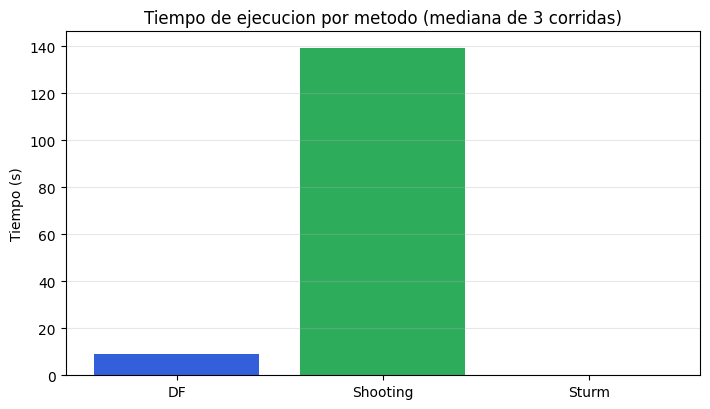

In [2]:
def run_timed(command, cwd, stdin_text=None):
    t0 = time.perf_counter()
    subprocess.run(
        command,
        cwd=cwd,
        input=stdin_text,
        text=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True,
    )
    return time.perf_counter() - t0

def median_runtime(method_fn, n_repeats=3):
    samples = [method_fn() for _ in range(n_repeats)]
    return float(np.median(samples)), samples

base = Path('.').resolve()
df_exec = base / 'finite-diferences' / 'leonardo' / 'leonardo_df'
shoot_exec = base / 'shooting-method' / 'litio_shooting'
sturm_exec = base / 'sturmSequence' / 'sturm_litio_cli'

for exe in [df_exec, shoot_exec, sturm_exec]:
    if not exe.exists():
        raise FileNotFoundError(f'No existe ejecutable: {exe}')

def run_df_total():
    # Suma de canales l=0,1,2
    t = 0.0
    t += run_timed([str(df_exec)], cwd=str(df_exec.parent), stdin_text='0\n')
    t += run_timed([str(df_exec)], cwd=str(df_exec.parent), stdin_text='1\n')
    t += run_timed([str(df_exec)], cwd=str(df_exec.parent), stdin_text='2\n')
    return t

def run_shoot_total():
    return run_timed([str(shoot_exec)], cwd=str(shoot_exec.parent))

def run_sturm_total():
    # Suma de canales l=0,1,2
    t = 0.0
    t += run_timed([str(sturm_exec)], cwd=str(sturm_exec.parent), stdin_text='0\n')
    t += run_timed([str(sturm_exec)], cwd=str(sturm_exec.parent), stdin_text='1\n')
    t += run_timed([str(sturm_exec)], cwd=str(sturm_exec.parent), stdin_text='2\n')
    return t

t_df_med, t_df_samples = median_runtime(run_df_total, n_repeats=3)
t_sh_med, t_sh_samples = median_runtime(run_shoot_total, n_repeats=3)
t_st_med, t_st_samples = median_runtime(run_sturm_total, n_repeats=3)

time_table = pd.DataFrame({
    'Metodo': ['DF', 'Shooting', 'Sturm'],
    'Tiempo_median_s': [t_df_med, t_sh_med, t_st_med],
    'Muestras_s': [t_df_samples, t_sh_samples, t_st_samples],
})

display(time_table[['Metodo', 'Tiempo_median_s']])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(time_table['Metodo'], time_table['Tiempo_median_s'], color=['#1d4ed8', '#16a34a', '#b45309'], alpha=0.9)
ax.set_title('Tiempo de ejecucion por metodo (mediana de 3 corridas)')
ax.set_ylabel('Tiempo (s)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparacion de tiempos de ejecucion (3 metodos)

Se mide el tiempo total por corrida para cada metodo.

Para los metodos por canal angular, se suma el tiempo de las corridas con $l=0,1,2$.

In [15]:
def load_wave_columns(path):
    # Algunos archivos traen cabecera sin '#'. La detectamos y la saltamos.
    with open(path, 'r', encoding='utf-8') as f:
        first = f.readline().strip().lower()
    has_header = first.startswith('r')
    arr = np.loadtxt(path, comments='#', skiprows=1 if has_header else 0)
    return arr[:, 0], arr

def load_sturm_blocks(path):
    arr = np.loadtxt(path)
    r = arr[:, 0]
    u = arr[:, 1]
    cuts = np.where(np.diff(r) < 0.0)[0]
    starts = [0] + (cuts + 1).tolist()
    ends = cuts.tolist() + [len(r)]
    blocks = []
    for i0, i1 in zip(starts, ends):
        blocks.append((r[i0:i1], u[i0:i1]))
    return blocks

# DF (Leonardo) contiene: r, psi_1(1s), psi_2(2s), psi_3(3s), psi_4(4s), psi_5(2p), psi_6(3p), psi_7(3d)
r_df, wf_df = load_wave_columns(f_df_w)
if wf_df.shape[1] < 8:
    raise ValueError('El archivo DF de Leonardo debe tener 8 columnas: r + psi_1..psi_7')

R_df = {
    '2s': wf_df[:, 2],
    '3s': wf_df[:, 3],
    '4s': wf_df[:, 4],
    '2p': wf_df[:, 5],
    '3p': wf_df[:, 6],
    '3d': wf_df[:, 7],
}

# Shooting: r, R_2s, R_3s, R_4s, R_2p, R_3p, R_3d
r_sh, wf_sh = load_wave_columns(f_shoot_w)
R_sh = {
    '2s': wf_sh[:, 1],
    '3s': wf_sh[:, 2],
    '4s': wf_sh[:, 3],
    '2p': wf_sh[:, 4],
    '3p': wf_sh[:, 5],
    '3d': wf_sh[:, 6],
}

# Sturm sequence por bloques:
# LITIO_STURM0.DAT (l=0): [1s, 2s, 3s, 4s]
# LITIO_STURM1.DAT (l=1): [2p, 3p, 4p, ...]
blocks_s = load_sturm_blocks(f_sturm_s)
blocks_p = load_sturm_blocks(f_sturm_p)
if len(blocks_s) < 4:
    raise ValueError('LITIO_STURM0.DAT debe contener al menos 4 bloques (1s,2s,3s,4s).')
if len(blocks_p) < 2:
    raise ValueError('LITIO_STURM1.DAT debe contener al menos 2 bloques (2p,3p).')

r_st_2s, u_st_2s = blocks_s[1]
r_st_3s, u_st_3s = blocks_s[2]
r_st_4s, u_st_4s = blocks_s[3]
r_st_2p, u_st_2p = blocks_p[0]
r_st_3p, u_st_3p = blocks_p[1]

R_st = {
    '2s': (r_st_2s, u_st_2s),
    '3s': (r_st_3s, u_st_3s),
    '4s': (r_st_4s, u_st_4s),
    '2p': (r_st_2p, u_st_2p),
    '3p': (r_st_3p, u_st_3p),
}

mask_df = (r_df >= 0.0) & (r_df <= 25.0)
mask_sh = (r_sh >= 0.0) & (r_sh <= 25.0)

print('Max |R(r)| en 0<=r<=25 (DF / shooting / sturm):')
for st in ['2s', '3s', '4s', '2p', '3p']:
    m_df = np.max(np.abs(R_df[st][mask_df]))
    m_sh = np.max(np.abs(R_sh[st][mask_sh]))
    r_st, u_st = R_st[st]
    mask_st = (r_st >= 0.0) & (r_st <= 25.0)
    m_st = np.max(np.abs(u_st[mask_st]))
    print(f"{st:>3}: DF={m_df:.3e}  shoot={m_sh:.3e}  sturm={m_st:.3e}")

Max |R(r)| en 0<=r<=25 (DF / shooting / sturm):
 2s: DF=3.244e-02  shoot=4.894e-01  sturm=5.026e-01
 3s: DF=2.268e-02  shoot=3.513e-01  sturm=3.514e-01
 4s: DF=2.140e-02  shoot=3.315e-01  sturm=3.315e-01
 2p: DF=2.860e-02  shoot=4.420e-01  sturm=4.431e-01
 3p: DF=2.128e-02  shoot=3.296e-01  sturm=3.296e-01


## Comparacion de funciones radiales: DF vs Shooting vs Sturm

Panel A muestra estados s y Panel B estados p.

El estado 3d se conserva en la tabla de energias, pero no se muestra en esta figura para mantener la comparacion visual centrada en s y p.

Sturm se lee por bloques en archivos separados para $l=0$ y $l=1$. En $l=0$ se omite el primer bloque (1s) y se usan 2s, 3s, 4s; en $l=1$ se usan 2p y 3p.

Para comparar forma (y evitar que una curva quede visualmente pegada al cero), cada curva se reescala por su maximo absoluto en la ventana mostrada $0 \le r \le 25$ u.a.

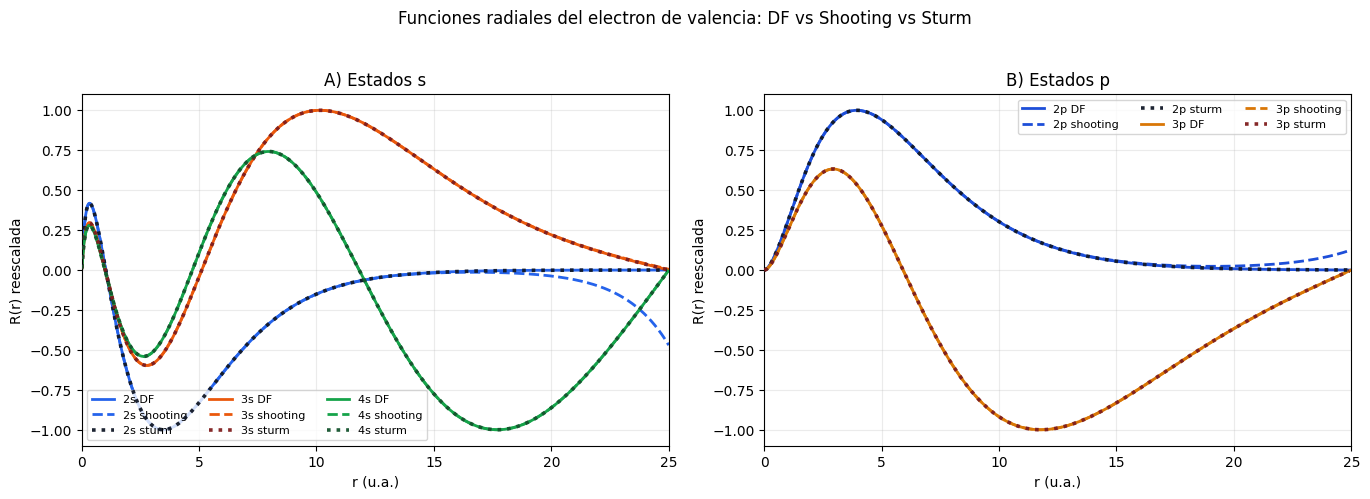

In [16]:
def normalize_in_window(r, y, rmin=0.0, rmax=25.0):
    m = (r >= rmin) & (r <= rmax)
    scale = np.max(np.abs(y[m]))
    if not np.isfinite(scale) or scale <= 0.0:
        return y
    return y / scale

sturm_colors = {
    '2s': '#111827',
    '3s': '#7f1d1d',
    '4s': '#14532d',
    '2p': '#111827',
    '3p': '#7f1d1d',
}

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), sharex=True)

# Estados s
for st, col in [('2s', '#2563eb'), ('3s', '#ea580c'), ('4s', '#16a34a')]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    r_st, u_st = R_st[st]
    y_st = normalize_in_window(r_st, u_st)
    axes[0].plot(r_df, y_df, color=col, lw=2.0, label=f'{st} DF')
    axes[0].plot(r_sh, y_sh, color=col, lw=2.0, ls='--', label=f'{st} shooting')
    axes[0].plot(
        r_st, y_st,
        color=sturm_colors[st], lw=2.6, ls=':', alpha=0.95, zorder=6,
        label=f'{st} sturm'
    )

axes[0].set_xlim(0.0, 25.0)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r) reescalada')
axes[0].set_title('A) Estados s')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=3)

# Estados p
for st, col in [('2p', '#1d4ed8'), ('3p', '#d97706')]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    r_st, u_st = R_st[st]
    y_st = normalize_in_window(r_st, u_st)
    axes[1].plot(r_df, y_df, color=col, lw=2.0, label=f'{st} DF')
    axes[1].plot(r_sh, y_sh, color=col, lw=2.0, ls='--', label=f'{st} shooting')
    axes[1].plot(
        r_st, y_st,
        color=sturm_colors[st], lw=2.6, ls=':', alpha=0.95, zorder=6,
        label=f'{st} sturm'
    )

axes[1].set_xlim(0.0, 25.0)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r) reescalada')
axes[1].set_title('B) Estados p')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, ncol=3)

plt.suptitle('Funciones radiales del electron de valencia: DF vs Shooting vs Sturm', y=1.03)
plt.tight_layout()
plt.show()